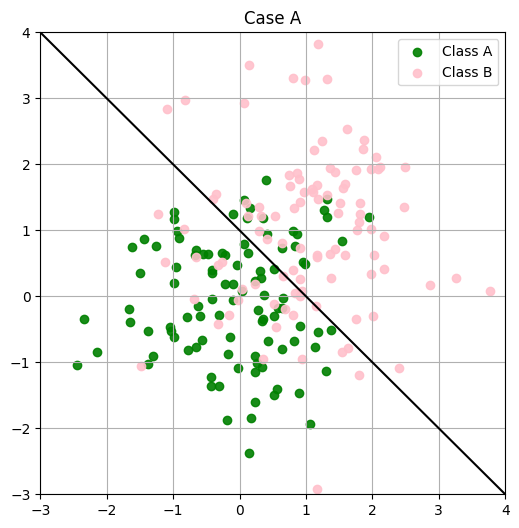

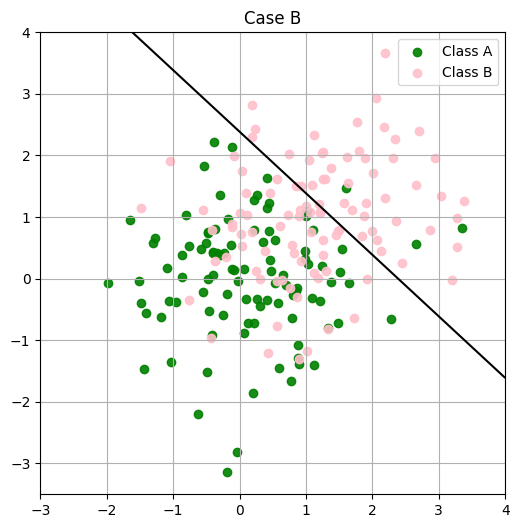

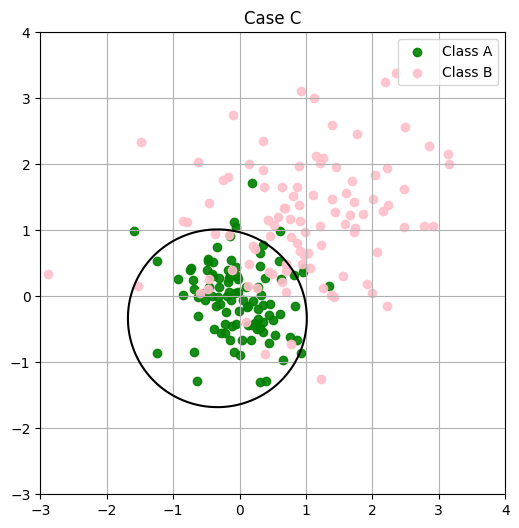

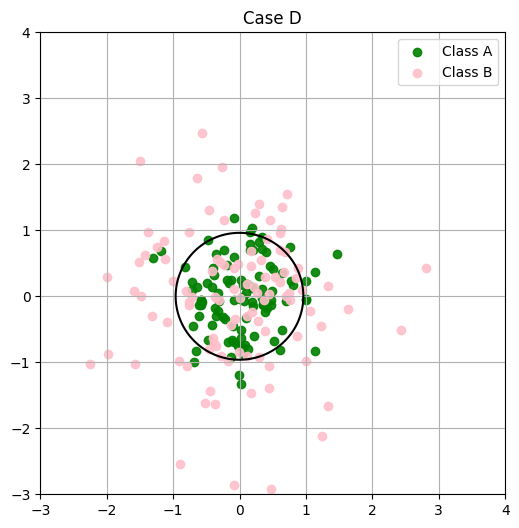

In [16]:


import numpy as np
import matplotlib.pyplot as plt

def plot_case(mu1, mu2, var1, var2, p, title):
    #100 random samples
    X_A = np.random.multivariate_normal(mu1, var1 * np.eye(2), 100)
    X_B = np.random.multivariate_normal(mu2, var2 * np.eye(2), 100)
    x = np.linspace(-3, 4, 200)
    y = np.linspace(-3, 4, 200)
    X, Y = np.meshgrid(x, y)

    #boundary function
    def boundary_func(x1, x2):
        d1 = (x1-mu1[0])**2 + (x2-mu1[1])**2
        d2 = (x1-mu2[0])**2 + (x2-mu2[1])**2
        term1 = -0.5*np.log(var1**2 * (2*np.pi)**2) - 0.5*(d1/var1) + np.log(p)
        term2 = -0.5*np.log(var2**2 * (2*np.pi)**2) - 0.5*(d2/var2) + np.log(1-p)
        return term1 - term2

    Z = boundary_func(X, Y)
    plt.figure(figsize=(6,6))
    plt.scatter(X_A[:,0], X_A[:,1], c='green', alpha=0.9, label='Class A')
    plt.scatter(X_B[:,0], X_B[:,1], c='pink', alpha=0.9, label='Class B')
    plt.contour(X, Y, Z, levels=[0], colors='black') # Boundary is where ratio = 0
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_case(mu1=[0,0], mu2=[1,1], var1=1, var2=1, p=0.5, title="Case A")
plot_case(mu1=[0,0], mu2=[1,1], var1=1, var2=1, p=0.8, title="Case B")
plot_case(mu1=[0,0], mu2=[1,1], var1=0.25, var2=1.0, p=0.5, title="Case C")
plot_case(mu1=[0,0], mu2=[0,0], var1=0.25, var2=1.0, p=0.5, title="Case D")


Question 4)

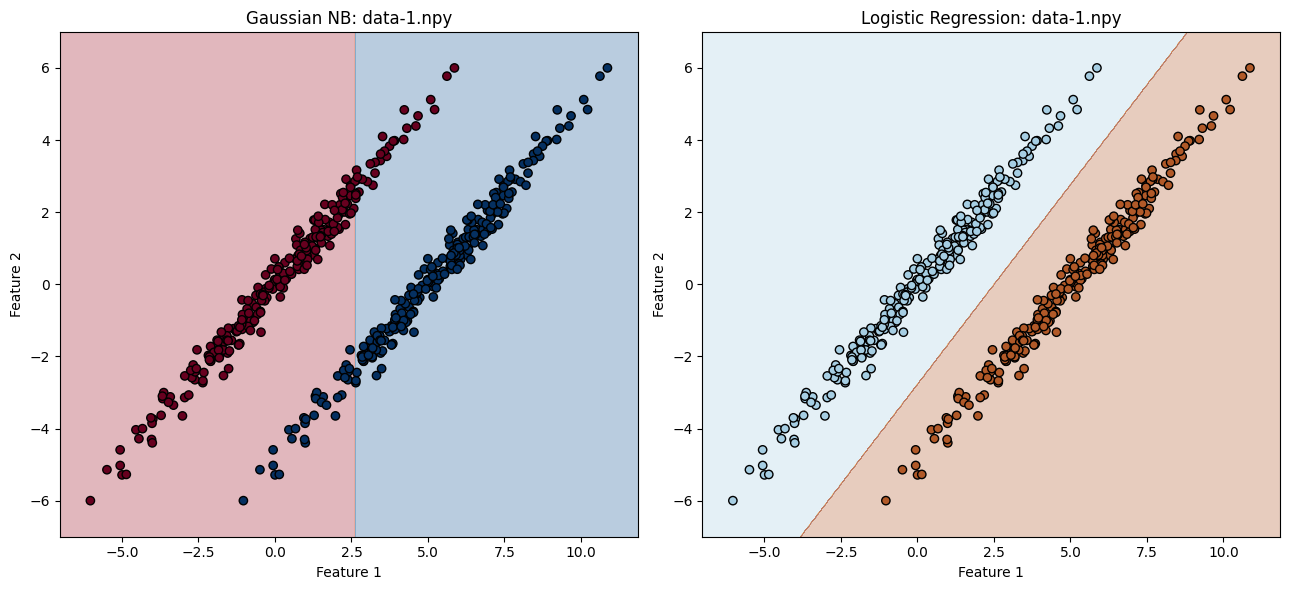

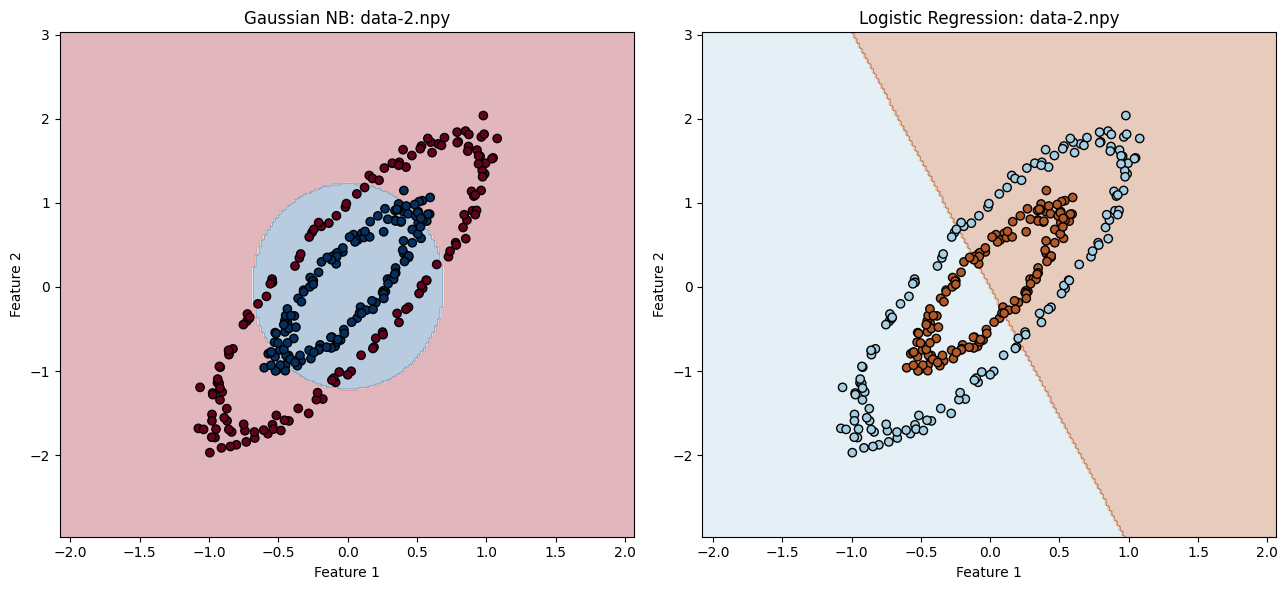

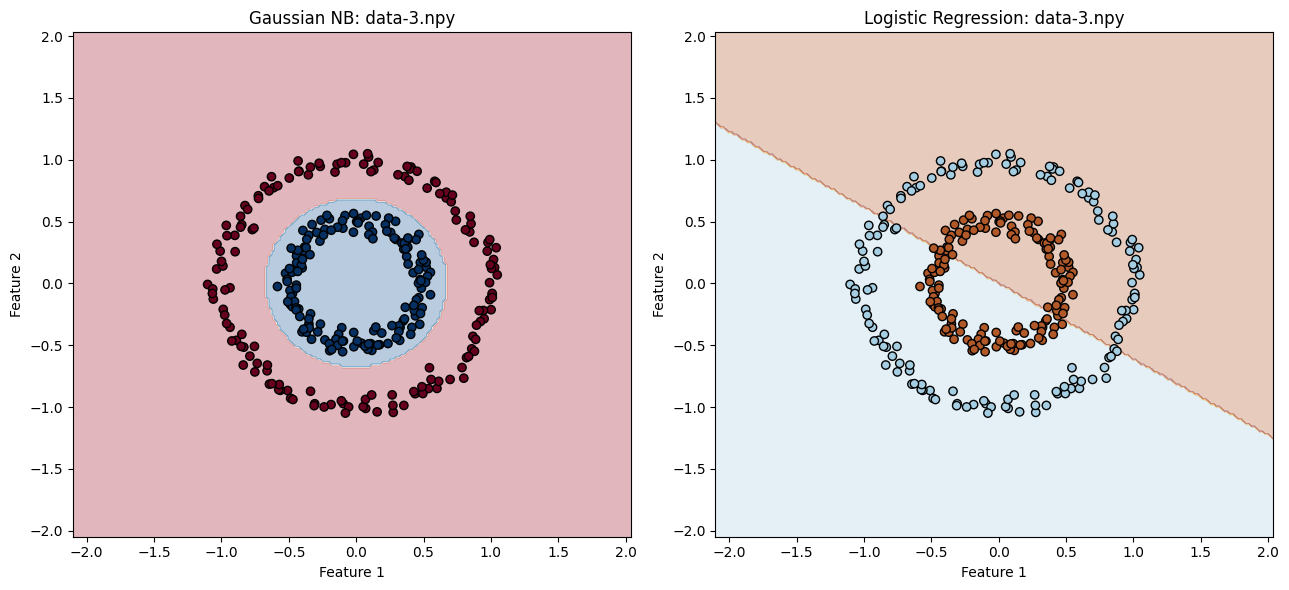

In [14]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

def plot_decision_boundaries(data_path, dataset_name):

    data = np.load(data_path)

    X = data[:, :2]
    y = data[:, 2]

    #fit the models
    gnb = GaussianNB()
    lr = LogisticRegression()

    gnb.fit(X, y)
    lr.fit(X, y)

    h = .02  #step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    #mesh grid
    Z_gnb = gnb.predict(np.c_[xx.ravel(), yy.ravel()])
    Z_lr = lr.predict(np.c_[xx.ravel(), yy.ravel()])

    #convert list of predictions to a 2d map
    Z_gnb = Z_gnb.reshape(xx.shape)
    Z_lr = Z_lr.reshape(xx.shape)

    plt.figure(figsize=(13, 6))

    #Gaussian naive bayes
    plt.subplot(1, 2, 1)
    plt.contourf(xx, yy, Z_gnb, alpha=0.3, cmap=plt.cm.RdBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='black', cmap=plt.cm.RdBu)
    plt.title(f'Gaussian NB: {dataset_name}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

    #logistic regression
    plt.subplot(1, 2, 2)
    plt.contourf(xx, yy, Z_lr, alpha=0.3, cmap=plt.cm.Paired)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='black', cmap=plt.cm.Paired)
    plt.title(f'Logistic Regression: {dataset_name}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

    plt.tight_layout()
    plt.show()

#run for all the 3 datasets
datasets = ['data-1.npy', 'data-2.npy', 'data-3.npy']
for ds in datasets:
    plot_decision_boundaries(ds, ds)


